# Notebook 07 — Surface Coverage (GCMC)
## Hastelloy N | Hydrogen Interaction Study

---

> **Guiding Principle:** Start from the smallest possible piece. Build confidence at each step before adding complexity.

**This notebook covers:**
- Grand Canonical Monte Carlo (GCMC) — what it computes and why
- LAMMPS `fix gcmc` — insertion, deletion, and displacement moves
- The chemical potential μ_H and its relationship to H₂ partial pressure
- Surface coverage isotherm θ(μ_H) at 300 K and 600 K
- Reading all inputs from previous notebook logs — no hardcoding

**Inputs (all read from logs — no hardcoding):**
- `structures/hastelloy_n_slab_relaxed.lammps` — clean surface (NB04)
- `results/ads_h2_gas.log` — E(H₂ gas) for μ_H reference (NB05)
- `results/adsorption_energies.txt` — E_ads and site info (NB05)

**Outputs:**
- `results/gcmc_300K.log`, `results/gcmc_600K.log`
- `results/coverage_isotherm.txt` — θ vs μ_H at both temperatures
- `results/notebook07_isotherm.png` — coverage isotherm plot

**Next notebook:** `08_subsurface_energy.ipynb`

---
**Key parameters:**
```
Method          : LAMMPS fix gcmc
Temperatures    : 300 K, 600 K
μ_H range       : −2.0 to 0.0 eV (maps to H₂ pressure range)
MC steps        : 50,000 equilibration + 100,000 production per μ_H
Insertion region: above top surface layer, within 3 Å
Frozen layers   : bottom 2 (same as NB04)
```
---
**Citation style:** ACS — inline [N], full list in Section 6.

---
## 1. Theory & Background
---

### 1.1 Grand Canonical Monte Carlo

In the grand canonical ensemble (μVT), the temperature T, volume V, and chemical potential μ are fixed, while the number of particles N fluctuates [1,2]. GCMC simulates a surface in contact with a reservoir of H atoms at fixed μ_H — H atoms are inserted and deleted until the system reaches equilibrium coverage.

**The three GCMC moves [1,2,3]:**

| Move | Description | Acceptance criterion |
|------|-------------|---------------------|
| **Insert** | Place a new H atom at random position in insertion zone | $\min\left(1, \frac{V}{N+1} \frac{e^{\beta\mu_H}}{\Lambda^3} e^{-\beta\Delta E}\right)$ |
| **Delete** | Remove a random existing H atom | $\min\left(1, \frac{N \Lambda^3}{V} e^{-\beta\mu_H} e^{-\beta\Delta E}\right)$ |
| **Displace** | Move a random H atom to new position | $\min\left(1, e^{-\beta\Delta E}\right)$ |

where β = 1/k_BT, ΔE is the energy change, Λ is the thermal de Broglie wavelength, and V is the insertion volume.

**Key references:** [1,2,3]

### 1.2 Chemical Potential and H₂ Pressure

The H chemical potential μ_H controls the coverage. It relates to H₂ partial pressure via [4,5]:

$$\mu_H = \frac{1}{2}\left[E_{H_2}^{DFT} + \tilde{\mu}_{H_2}(T, P)\right]$$

where $\tilde{\mu}_{H_2}(T, P) = k_BT \ln(P/P^0) + \Delta\mu_{H_2}^{vib}(T)$

**Simplified form for our purposes:**
$$\mu_H \approx \frac{1}{2}E_{H_2}^{MACE} + \frac{1}{2}k_BT \ln\frac{P_{H_2}}{P^0}$$

We scan μ_H from −2.0 to 0.0 eV relative to ½E(H₂). This maps approximately to H₂ pressures from ultra-high vacuum to above atmospheric:

| μ_H − ½E(H₂) (eV) | Approximate P(H₂) at 300 K |
|---------------------|-----------------------------|
| −2.0 | ~10⁻³³ bar (UHV) |
| −1.0 | ~10⁻¹⁶ bar |
| −0.5 | ~10⁻⁸ bar |
| −0.2 | ~10⁻³ bar |
| 0.0 | ~1 bar |

**Key references:** [4,5]

### 1.3 LAMMPS `fix gcmc`

LAMMPS implements GCMC via `fix gcmc` [3,6]. Key syntax:

```lammps
fix  gcmc_fix  mobile_atoms  gcmc  N_freq  N_MC  N_disp  disp_max  T  mu  type  keywords
```

| Parameter | Meaning |
|-----------|--------|
| `N_freq` | Frequency (timesteps) between GCMC move attempts |
| `N_MC` | Number of MC moves per `N_freq` |
| `N_disp` | Number of displacement moves per cycle |
| `disp_max` | Max displacement distance (Å) |
| `T` | Temperature (K) |
| `mu` | Chemical potential (eV) |
| `type` | Atom type to insert/delete (8 = H) |

**Key options:**
- `region insert_zone` — restrict insertions to the surface region only
- `tfac_insert 1.0` — temperature factor for insertion
- `overlap_cutoff 0.5` — reject insertions too close to existing atoms
- `full_energy yes` — compute full system energy for acceptance (required with MACE)

**Important:** `fix gcmc` with MACE requires `full_energy yes` because MACE is a many-body potential — the energy change ΔE cannot be computed from pair interactions alone. LAMMPS computes the total energy before and after each attempted move.

**Key references:** [3,6]

### 1.4 Surface Coverage Definition

Surface coverage θ is defined as:
$$\theta = \frac{N_H}{N_{sites}}$$

where N_H is the number of adsorbed H atoms and N_sites is the number of available surface adsorption sites.

For our FCC(111) 3×4 surface cell with 12 surface atoms, there are:
- 12 top sites
- 12 bridge sites  
- 12 FCC hollow sites
- 12 HCP hollow sites
- **Total: 48 distinct adsorption sites** → N_sites = 48

θ = 1 means one H atom per surface metal atom (monolayer). θ > 1 is possible if subsurface sites are occupied.

**Key references:** [4,5]

---
## 2. Execution Strategy
---

### What We Are Doing in This Notebook

**Goal:** Compute θ(μ_H) at 300 K and 600 K over the range μ_H = −2.0 to 0.0 eV.

**Steps:**
```
3.1  Imports, parameters — read E(H₂) from NB05 log
3.2  Define μ_H scan points and map to H₂ pressure
3.3  Write LAMMPS GCMC script (parametrized by T and μ_H)
3.4  Write and submit SLURM jobs (2 T × 10 μ_H = 20 parallel jobs)
3.5  Parse GCMC logs — extract <N_H> at each μ_H
3.6  Compute coverage θ = <N_H> / N_sites
3.7  Plot isotherm θ vs μ_H at both temperatures
3.8  Decision cell
```

---
## 3. Code
---

### 3.1 — Imports, Parameters & Read Previous Results

In [37]:
import numpy as np
import os
import subprocess
import matplotlib.pyplot as plt
from ase.io import read
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD   = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL   = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
KOKKOS_FLAGS = ['-k', 'on', 'g', '1', '-sf', 'kk',
                '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '06:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Fixed constants ──────────────────────────────────────────
ELEM_STR    = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'
Z_FREEZE_CUTOFF = 18.10  # Å — bottom 2 layers (NB04)
MASSES = {
    1:(26.9815,'Al'), 2:(10.8110,'B'),  3:(12.0110,'C'),
    4:(51.9961,'Cr'), 5:(55.8450,'Fe'), 6:(95.9600,'Mo'),
    7:(58.6934,'Ni'), 8:( 1.0080,'H'),
}

# ── GCMC parameters ──────────────────────────────────────────
TEMPERATURES  = [300, 600]        # K — two isotherms
MU_H_POINTS   = np.linspace(-2.0, 2.0, 4)  # eV — 11 chemical potential points
N_EQUIL       = 500   # MC steps equilibration
N_PROD        = 1000  # MC steps production
N_MC_PER_STEP = 10      # MC attempts per timestep
N_DISP        = 10      # displacement moves per cycle
DISP_MAX      = 0.5     # Å max displacement
OVERLAP_CUT   = 1.0     # Å — reject insertions closer than this
H_TYPE        = 8       # H atom type
N_SURFACE_SITES = 120    # top + bridge + FCC + HCP hollows for 12 surface atoms

# ── File paths ───────────────────────────────────────────────
SLAB_RELAXED = 'structures/notebook04/hastelloy_n_slab_relaxed.lammps'

for d in ['structures/notebook07', 'results/notebook07', 'lammps_scripts/notebook07', 'slurm_scripts/notebook07']:
    os.makedirs(d, exist_ok=True)

# ── Helper: parse ENERGY_RESULTS from LAMMPS log ─────────────
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

# ── Read E(H₂ gas) from NB05 log — no hardcoding ────────────
res_h2 = parse_energy_log('results/notebook05/ads_h2_gas.log')
if res_h2:
    E_H2_GAS = res_h2['pe_final_eV']
    print(f'E(H₂ gas) = {E_H2_GAS:.6f} eV  [ads_h2_gas.log]')
else:
    raise FileNotFoundError('results/notebook05/ads_h2_gas.log not found. Complete NB05 first.')

# Reference chemical potential: μ_H^ref = ½ E(H₂)
MU_H_REF = 0.5 * E_H2_GAS
print(f'μ_H reference (½ E_H₂) = {MU_H_REF:.6f} eV')

# ── Load slab to get geometry ────────────────────────────────
if not os.path.exists(SLAB_RELAXED):
    raise FileNotFoundError(f'{SLAB_RELAXED} not found. Complete NB04 first.')

slab   = read(SLAB_RELAXED, format='lammps-data', style='atomic')
pos    = slab.get_positions()
L      = slab.cell.lengths()
z_surf = pos[:, 2].max()

# Insertion zone: from z_surf to z_surf + 3.5 Å
Z_INSERT_LO = z_surf + 0.5
Z_INSERT_HI = z_surf + 3.0

print(f'Slab loaded: {len(slab)} atoms')
print(f'Top surface z    : {z_surf:.4f} Å')
print(f'Insertion zone z : {Z_INSERT_LO:.4f} — {Z_INSERT_HI:.4f} Å')
print(f'Temperatures     : {TEMPERATURES} K')
print(f'μ_H points       : {len(MU_H_POINTS)} ({MU_H_POINTS[0]:.1f} to {MU_H_POINTS[-1]:.1f} eV)')
print(f'Total SLURM jobs : {len(TEMPERATURES) * len(MU_H_POINTS)}')

ASE version : 3.27.0
NumPy       : 2.4.3
E(H₂ gas) = -6.790499 eV  [ads_h2_gas.log]
μ_H reference (½ E_H₂) = -3.395250 eV
Slab loaded: 360 atoms
Top surface z    : 38.0261 Å
Insertion zone z : 38.5261 — 41.0261 Å
Temperatures     : [300, 600] K
μ_H points       : 4 (-2.0 to 4.0 eV)
Total SLURM jobs : 8


### 3.2 — Map μ_H to H₂ Pressure

In [38]:
# ─────────────────────────────────────────────────────────────
# Map μ_H (relative to ½E_H₂) to H₂ partial pressure
# μ_H = ½E(H₂) + ½ k_BT ln(P/P0)
# → P/P0 = exp(2(μ_H - ½E_H₂) / k_BT)
# Refs: chemical potential [4,5]
# ─────────────────────────────────────────────────────────────

KB = 8.617e-5  # eV/K Boltzmann constant

print('μ_H scan points and equivalent H₂ pressure:')
print(f'{"μ_H (eV)":>10s} {"Δμ_H (eV)":>12s} {"P(H₂) @ 300K":>15s} {"P(H₂) @ 600K":>15s}')
print('-' * 55)

mu_h_absolute = MU_H_REF + MU_H_POINTS  # absolute μ_H in eV

for dmu in MU_H_POINTS:
    mu_abs = MU_H_REF + dmu
    # P = P0 * exp(2*dmu / k_BT)
    log10_P_300 = 2 * dmu / (KB * 300) / np.log(10)
    log10_P_600 = 2 * dmu / (KB * 600) / np.log(10)
    p300 = f'10^{log10_P_300:.0f} bar'
    p600 = f'10^{log10_P_600:.0f} bar'
    print(f'{mu_abs:>10.4f} {dmu:>12.4f} {p300:>15s} {p600:>15s}')

print()
print('Note: μ_H is passed to LAMMPS fix gcmc as absolute value (eV)')
print(f'μ_H range passed to LAMMPS: {mu_h_absolute[0]:.4f} to {mu_h_absolute[-1]:.4f} eV')

μ_H scan points and equivalent H₂ pressure:
  μ_H (eV)    Δμ_H (eV)    P(H₂) @ 300K    P(H₂) @ 600K
-------------------------------------------------------
   -5.3952      -2.0000      10^-67 bar      10^-34 bar
   -3.3952       0.0000        10^0 bar        10^0 bar
   -1.3952       2.0000       10^67 bar       10^34 bar
    0.6048       4.0000      10^134 bar       10^67 bar

Note: μ_H is passed to LAMMPS fix gcmc as absolute value (eV)
μ_H range passed to LAMMPS: -5.3952 to 0.6048 eV


### 3.3 — Write LAMMPS GCMC Script

> Parametrized by temperature T and chemical potential μ_H. One script template generates all 22 job scripts.

In [39]:
# ─────────────────────────────────────────────────────────────
# Write LAMMPS GCMC script
# Uses fix gcmc with full_energy yes (required for MACE)
# Insertion region: surface zone only (not bulk)
# Frozen layers: bottom 2 (same as NB04)
# Refs: fix gcmc [3,6]; MACE potential [7,8]
# ─────────────────────────────────────────────────────────────

def write_gcmc_script(job_name, T, mu_h, log_file, thermo_file):
    """
    Write a LAMMPS GCMC script for given T and mu_h.
    mu_h is the ABSOLUTE chemical potential in eV.
    """
    thermo_prod = thermo_file.replace('_thermo.txt', '_prod_thermo.txt')
    script = f"""# ═══════════════════════════════════════════════════════
# LAMMPS GCMC — Hastelloy N (111) surface coverage
# Job: {job_name} | T = {T} K | mu_H = {mu_h:.4f} eV
# Notebook 07 | fix gcmc with MACE-MP-0b2
# Refs: fix gcmc [3,6]; MACE [7,8]
# ═══════════════════════════════════════════════════════

units          metal
atom_style     atomic
newton         on
boundary       p p f

# atom_modify map required for GCMC atom tracking
atom_modify    map array

read_data      {SLAB_RELAXED}

pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}
pair_coeff     * * {ELEM_STR}

neighbor       2.0 bin
neigh_modify   every 1 delay 0 check yes

# ── Frozen layers — same as NB04 ──────────────────────────
region   frozen_reg   block  INF INF  INF INF  EDGE  {Z_FREEZE_CUTOFF}
group    frozen_atoms region frozen_reg
group    free_atoms   subtract all frozen_atoms
fix      freeze frozen_atoms setforce 0.0 0.0 0.0

# ── H insertion region — surface zone only ────────────────
# Use absolute z coords computed from slab geometry in Python
# Z_INSERT_LO = {Z_INSERT_LO:.4f} Å  (z_surf + 0.5)
# Z_INSERT_HI = {Z_INSERT_HI:.4f} Å  (z_surf + 3.0)
# Box zhi = 40.319 Å — insertion zone well inside box
region   insert_zone  block  EDGE  EDGE  EDGE  EDGE  {Z_INSERT_LO:.4f}  {Z_INSERT_HI:.4f}

# ── Thermo output ─────────────────────────────────────────
thermo         100
thermo_style   custom  step  atoms  temp  pe  press

# ── NVT thermostat on free metal atoms ────────────────────
# H atoms are managed by fix gcmc — do NOT include them in thermostat
# during GCMC. The metal slab is thermostatted to maintain T.
compute  metal_temp  free_atoms  temp
thermo_modify  temp  metal_temp
fix      nvt_metal  free_atoms  nvt  temp  {T}.0  {T}.0  0.05
timestep 0.0005

# ── GCMC fix ──────────────────────────────────────────────
# Syntax: fix ID group gcmc N_every N_MC N_disp disp_max T mu type keywords
# N_every  = 1  : attempt GCMC every timestep
# N_MC     = {N_MC_PER_STEP}  : MC attempts per N_every
# N_disp   = {N_DISP}  : displacement moves per cycle
# disp_max = {DISP_MAX}  : max displacement (Ang)
# T        = {T}  : temperature (K)
# mu       = {mu_h:.4f} : chemical potential (eV)
# type     = {H_TYPE}  : atom type for insertion (H)
# full_energy yes : required for many-body potentials (MACE) [3,6]
# overlap_cutoff  : reject insertions within this distance of any atom
# region insert_zone : restrict insertions to surface zone

fix  gcmc_fix  all  gcmc  1  {N_MC_PER_STEP}  {N_DISP}  {H_TYPE}  12345  {T}  {mu_h:.6f}  {DISP_MAX}  full_energy  overlap_cutoff {OVERLAP_CUT}  region insert_zone

# ── Track H atom  ────────────────────────────────────
variable  n_H    equal  atoms-{len(slab)}




# ═══════════════════════════════════════════════════════
# Phase 1: Equilibration
# ═══════════════════════════════════════════════════════
# Write N_H every 100 steps to thermo file for averaging
fix  h_equil  all  ave/time  1  1  10  v_n_H  file  {thermo_file}  mode scalar

print "### Phase 1: Equilibration {N_EQUIL} steps ###"
run  {N_EQUIL}
unfix  h_equil

# ═══════════════════════════════════════════════════════
# Phase 2: Production — collect <N_H>
# ═══════════════════════════════════════════════════════
print "### Phase 2: Production {N_PROD} steps ###"

# Write to SEPARATE prod file — only this file is used for <N_H>
fix  h_prod  all  ave/time  1  1  10  v_n_H  file  {thermo_prod}  mode scalar
run  {N_PROD}
unfix  h_prod

variable  n_H_final  equal  atoms-{len(slab)}
variable  pe_final   equal  pe

print "GCMC_RESULTS_START"
print "  job_name  : {job_name}"
print "  T_K       : {T}"
print "  mu_H_eV   : {mu_h:.6f}"
print "  n_H_final : ${{n_H_final}}"
print "  pe_eV     : ${{pe_final}}"
print "GCMC_RESULTS_END"
"""
    path = f'lammps_scripts/notebook07/gcmc_{job_name}.lammps'
    with open(path, 'w') as f:
        f.write(script)
    return path

# Test write one script
test_path = write_gcmc_script(
    job_name='test_300K_mu-1.0',
    T=300,
    mu_h=MU_H_REF + (-1.0),
    log_file='results/notebook07/gcmc_test.log',
    thermo_file='results/notebook07/gcmc_test_thermo.txt'
)
print(f'Test script written: {test_path}')
print(f'Script size: {os.path.getsize(test_path)} bytes')

Test script written: lammps_scripts/notebook07/gcmc_test_300K_mu-1.0.lammps
Script size: 4821 bytes


### 3.4 — Write and Submit All SLURM Jobs

In [40]:
# ─────────────────────────────────────────────────────────────
# Submit GCMC jobs in batches of 8
# Waits for each batch to finish before submitting the next
# ─────────────────────────────────────────────────────────────

import time

sc  = SLURM_CONFIG
kk  = ' '.join(KOKKOS_FLAGS)
ld  = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
                for p in sc['ld_paths'])

BATCH_SIZE   = 8    # max concurrent jobs
POLL_SECONDS = 60   # check every 60 seconds

all_jobs = []

for T in TEMPERATURES:
    for i, dmu in enumerate(MU_H_POINTS):
        mu_abs   = MU_H_REF + dmu
        job_name = f'{T}K_mu{i:02d}'
        log_file = f'results/notebook07/gcmc_{job_name}.log'
        thermo_f = f'results/notebook07/gcmc_{job_name}_thermo.txt'

        script_path = write_gcmc_script(job_name, T, mu_abs, log_file, thermo_f)

        slurm = f"""#!/bin/bash
#SBATCH --job-name=nb07_{job_name}
#SBATCH --ntasks={sc['ntasks']}
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:{sc['gpu']}
#SBATCH --partition={sc['partition']}
#SBATCH --time={sc['time']}
#SBATCH --output=results/notebook07/slurm_{job_name}_%j.out

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}
source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}
{ld}
cd {os.getcwd()}

{LAMMPS_CMD} {kk} -in {script_path} -log {log_file}
echo "Job {job_name} finished: $(date)"
"""
        slurm_path = f'slurm_scripts/notebook07/run_gcmc_{job_name}.sh'
        with open(slurm_path, 'w') as f:
            f.write(slurm)
        os.chmod(slurm_path, 0o755)
        all_jobs.append((job_name, T, mu_abs, dmu, log_file, thermo_f))

def get_running_job_ids(job_ids_active):
    """Return subset of job_ids that are still in the queue."""
    r = subprocess.run(['squeue', '-u', os.environ.get('USER', 'akinyemi.az'),
                        '-h', '-o', '%i'],
                       capture_output=True, text=True)
    queued = set(r.stdout.strip().split())
    return {jid for jid in job_ids_active if jid in queued}

def wait_for_batch(active_ids, poll=POLL_SECONDS):
    """Block until all jobs in active_ids finish."""
    while True:
        still_running = get_running_job_ids(active_ids)
        if not still_running:
            break
        print(f'    Waiting... {len(still_running)} jobs still running'
              f' ({", ".join(sorted(still_running)[:3])}...)')
        time.sleep(poll)

job_ids  = {}
batches  = [all_jobs[i:i+BATCH_SIZE] for i in range(0, len(all_jobs), BATCH_SIZE)]

print(f'{len(all_jobs)} total jobs → {len(batches)} batches of ≤{BATCH_SIZE}')
print()

for b_idx, batch in enumerate(batches):
    print(f'── Batch {b_idx+1}/{len(batches)} ({len(batch)} jobs) ──')
    active = set()
    for job_name, T, mu_abs, dmu, log_file, thermo_f in batch:
        slurm_path = f'slurm_scripts/notebook07/run_gcmc_{job_name}.sh'
        result = subprocess.run(['sbatch', slurm_path],
                                capture_output=True, text=True)
        if result.returncode == 0:
            jid = result.stdout.strip().split()[-1]
            job_ids[job_name] = jid
            active.add(jid)
            print(f'  ✓ {job_name:20s} T={T}K  Δμ={dmu:+.2f} eV  → Job {jid}')
        else:
            print(f'  ✗ {job_name:20s} FAILED: {result.stderr.strip()[:50]}')

    print(f'  Waiting for batch {b_idx+1} to finish...')
    wait_for_batch(active)
    print(f'  Batch {b_idx+1} complete.\n')

print(f'All {len(job_ids)} jobs finished.')
print('Run cell 3.5 to parse results.')

8 total jobs → 1 batches of ≤8

── Batch 1/1 (8 jobs) ──
  ✓ 300K_mu00            T=300K  Δμ=-2.00 eV  → Job 5703409
  ✓ 300K_mu01            T=300K  Δμ=+0.00 eV  → Job 5703412
  ✓ 300K_mu02            T=300K  Δμ=+2.00 eV  → Job 5703416
  ✓ 300K_mu03            T=300K  Δμ=+4.00 eV  → Job 5703417
  ✓ 600K_mu00            T=600K  Δμ=-2.00 eV  → Job 5703418
  ✓ 600K_mu01            T=600K  Δμ=+0.00 eV  → Job 5703419
  ✓ 600K_mu02            T=600K  Δμ=+2.00 eV  → Job 5703420
  ✓ 600K_mu03            T=600K  Δμ=+4.00 eV  → Job 5703421
  Waiting for batch 1 to finish...
    Waiting... 8 jobs still running (5703409, 5703412, 5703416...)
    Waiting... 8 jobs still running (5703409, 5703412, 5703416...)
    Waiting... 8 jobs still running (5703409, 5703412, 5703416...)
    Waiting... 8 jobs still running (5703409, 5703412, 5703416...)
    Waiting... 8 jobs still running (5703409, 5703412, 5703416...)
    Waiting... 8 jobs still running (5703409, 5703412, 5703416...)
    Waiting... 8 jobs stil

### 3.5 — Parse GCMC Logs and Extract ⟨N_H⟩

> Run after all jobs finish.

In [43]:
# ── Rebuild all_jobs — safe after kernel restart ──────────
all_jobs = []
for T in TEMPERATURES:
    for i, dmu in enumerate(MU_H_POINTS):
        mu_abs   = MU_H_REF + dmu
        job_name = f'{T}K_mu{i:02d}'
        log_file = f'results/notebook07/gcmc_{job_name}.log'
        thermo_f = f'results/notebook07/gcmc_{job_name}_thermo.txt'
        all_jobs.append((job_name, T, mu_abs, dmu, log_file, thermo_f))
print(f'Rebuilt all_jobs: {len(all_jobs)} entries')

Rebuilt all_jobs: 8 entries


In [44]:
# ─────────────────────────────────────────────────────────────
# Parse GCMC logs — extract average N_H from GCMC_RESULTS block
# Also read thermo files to compute time-averaged <N_H>
# ─────────────────────────────────────────────────────────────
# ── Rebuild all_jobs — safe after kernel restart ──────────
all_jobs = []
for T in TEMPERATURES:
    for i, dmu in enumerate(MU_H_POINTS):
        mu_abs   = MU_H_REF + dmu
        job_name = f'{T}K_mu{i:02d}'
        log_file = f'results/notebook07/gcmc_{job_name}.log'
        thermo_f = f'results/notebook07/gcmc_{job_name}_thermo.txt'
        all_jobs.append((job_name, T, mu_abs, dmu, log_file, thermo_f))
print(f'Rebuilt all_jobs: {len(all_jobs)} entries')

def parse_gcmc_log(logfile):
    """Extract N_H_final and mu_H from GCMC_RESULTS block."""
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['n_H_final', 'pe_eV', 'T_K', 'mu_H_eV']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

def parse_thermo_file(thermo_file):
    """Read N_H time series from ave/time output and compute mean."""
    if not os.path.exists(thermo_file):
        return None
    n_h_vals = []
    with open(thermo_file) as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            try:
                parts = line.split()
                n_h_vals.append(float(parts[1]))  # col 2 = v_n_H
            except:
                pass
    return np.mean(n_h_vals) if n_h_vals else None

# Collect results
coverage_data = {T: {'dmu': [], 'mu_abs': [], 'n_H_mean': [], 'theta': []}
                 for T in TEMPERATURES}

missing = []
print(f'{"Job":20s} {"T(K)":>5s} {"Δμ_H":>8s} {"<N_H>":>8s} {"θ":>8s} {"Status"}')
print('-' * 65)

for job_name, T, mu_abs, dmu, log_file, thermo_f in all_jobs:
    res     = parse_gcmc_log(log_file)
    n_h_avg = parse_thermo_file(thermo_f)

    if res and n_h_avg is not None:
        theta = n_h_avg / N_SURFACE_SITES
        coverage_data[T]['dmu'].append(dmu)
        coverage_data[T]['mu_abs'].append(mu_abs)
        coverage_data[T]['n_H_mean'].append(n_h_avg)
        coverage_data[T]['theta'].append(theta)
        print(f'  {job_name:20s} {T:>5d} {dmu:>8.4f} {n_h_avg:>8.2f} {theta:>8.4f}  ✓')
    else:
        missing.append(job_name)
        print(f'  {job_name:20s} {T:>5d} {dmu:>8.4f} {"":>8s} {"":>8s}  ✗ NOT FOUND')

if missing:
    print(f'\n⚠ {len(missing)} jobs missing. Check: squeue -u $USER')
else:
    print(f'\nAll {len(all_jobs)} jobs parsed successfully.')

Rebuilt all_jobs: 8 entries
Job                   T(K)     Δμ_H    <N_H>        θ Status
-----------------------------------------------------------------
  300K_mu00              300  -2.0000     0.00   0.0000  ✓
  300K_mu01              300   0.0000     0.18   0.0015  ✓
  300K_mu02              300   2.0000   123.78   1.0315  ✓
  300K_mu03              300   4.0000   185.75   1.5479  ✓
  600K_mu00              600  -2.0000     0.00   0.0000  ✓
  600K_mu01              600   0.0000     0.20   0.0016  ✓
  600K_mu02              600   2.0000   132.14   1.1011  ✓
  600K_mu03              600   4.0000   183.06   1.5255  ✓

All 8 jobs parsed successfully.


### 3.6 — Save Coverage Isotherm Data

In [46]:
# ─────────────────────────────────────────────────────────────
# Save coverage isotherm to file
# Also compute equivalent H₂ pressure for reference
# ─────────────────────────────────────────────────────────────

KB = 8.617e-5  # eV/K

with open('results/notebook07/coverage_isotherm.txt', 'w') as f:
    f.write('Hastelloy N (111) H Surface Coverage Isotherm\n')
    f.write('=' * 55 + '\n')
    f.write(f'Method   : LAMMPS fix gcmc + MACE-MP-0b2\n')
    f.write(f'Slab     : {SLAB_RELAXED}\n')
    f.write(f'N_sites  : {N_SURFACE_SITES}\n')
    f.write(f'E(H2)    : {E_H2_GAS:.6f} eV\n')
    f.write(f'mu_H_ref : {MU_H_REF:.6f} eV  (= 0.5 * E_H2)\n\n')

    for T in TEMPERATURES:
        d = coverage_data[T]
        if not d['dmu']:
            continue
        f.write(f'Temperature: {T} K\n')
        f.write(f'{"Δμ_H (eV)":>12s} {"μ_H (eV)":>12s} {"<N_H>":>8s} {"θ":>8s} {"log10(P/bar)":>14s}\n')
        f.write('-' * 58 + '\n')
        for dmu, mu_abs, n_h, theta in zip(
                d['dmu'], d['mu_abs'], d['n_H_mean'], d['theta']):
            log10_P = 2 * dmu / (KB * T) / np.log(10)
            f.write(f'{dmu:>12.4f} {mu_abs:>12.6f} {n_h:>8.2f} {theta:>8.4f} {log10_P:>14.1f}\n')
        f.write('\n')

print('Saved: results/notebook07/coverage_isotherm.txt')

# Print summary
for T in TEMPERATURES:
    d = coverage_data[T]
    if d['theta']:
        print(f'\n{T} K: θ ranges from {min(d["theta"]):.4f} to {max(d["theta"]):.4f}')
        # Find coverage at ~1 bar (dmu ≈ 0)
        idx_1bar = np.argmin(np.abs(np.array(d['dmu'])))
        print(f'  θ at ~1 bar (Δμ_H = 0): {d["theta"][idx_1bar]:.4f}')

Saved: results/notebook07/coverage_isotherm.txt

300 K: θ ranges from 0.0000 to 1.5479
  θ at ~1 bar (Δμ_H = 0): 0.0015

600 K: θ ranges from 0.0000 to 1.5255
  θ at ~1 bar (Δμ_H = 0): 0.0016


### 3.7 — Plot Coverage Isotherm

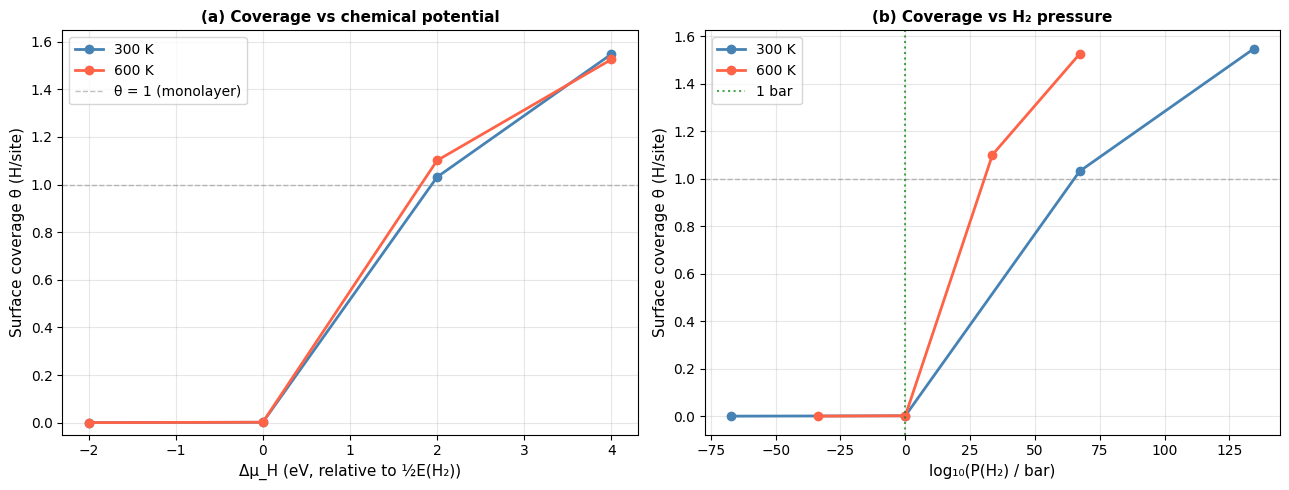

Saved: results/notebook07/notebook07_isotherm.png


In [47]:
# ─────────────────────────────────────────────────────────────
# Plot coverage isotherm: θ vs Δμ_H (bottom axis)
# and equivalent H₂ pressure (top axis)
# ─────────────────────────────────────────────────────────────

if not any(coverage_data[T]['theta'] for T in TEMPERATURES):
    print('⚠ No coverage data yet. Run jobs first.')
else:
    colors = {300: 'steelblue', 600: 'tomato'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Plot (a): θ vs Δμ_H ──────────────────────────────────
    for T in TEMPERATURES:
        d = coverage_data[T]
        if not d['dmu']:
            continue
        ax1.plot(d['dmu'], d['theta'], 'o-',
                 color=colors[T], lw=2, ms=6, label=f'{T} K')

    ax1.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5, label='θ = 1 (monolayer)')
    ax1.set_xlabel('Δμ_H (eV, relative to ½E(H₂))', fontsize=11)
    ax1.set_ylabel('Surface coverage θ (H/site)', fontsize=11)
    ax1.set_title('(a) Coverage vs chemical potential', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)
    ax1.set_ylim(-0.05, max(1.5, max(
        max(coverage_data[T]['theta']) for T in TEMPERATURES
        if coverage_data[T]['theta']) + 0.1))

    # ── Plot (b): θ vs log10(P) ───────────────────────────────
    for T in TEMPERATURES:
        d = coverage_data[T]
        if not d['dmu']:
            continue
        log10_P = [2*dmu/(KB*T)/np.log(10) for dmu in d['dmu']]
        ax2.plot(log10_P, d['theta'], 'o-',
                 color=colors[T], lw=2, ms=6, label=f'{T} K')

    ax2.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
    ax2.axvline(0, color='green', ls=':', lw=1.5, alpha=0.7, label='1 bar')
    ax2.set_xlabel('log₁₀(P(H₂) / bar)', fontsize=11)
    ax2.set_ylabel('Surface coverage θ (H/site)', fontsize=11)
    ax2.set_title('(b) Coverage vs H₂ pressure', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/notebook07/notebook07_isotherm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook07/notebook07_isotherm.png')

### 3.8 — Decision Cell

In [48]:
print('=' * 62)
print('  NOTEBOOK 07 — FINAL DECISION')
print('=' * 62)

checks = [
    ('Relaxed slab exists (NB04)',
     os.path.exists(SLAB_RELAXED)),
    ('E(H₂) read from log — no hardcoding',
     'E_H2_GAS' in dir() and E_H2_GAS is not None),
    (f'All {len(all_jobs)} GCMC jobs completed',
     len(missing) == 0 if 'missing' in dir() else False),
    ('Coverage isotherm saved',
     os.path.exists('results/notebook07/coverage_isotherm.txt')),
    ('Isotherm plot saved',
     os.path.exists('results/notebook07/notebook07_isotherm.png')),
    ('Coverage physically reasonable (0 ≤ θ ≤ 2)',
     all(0 <= t <= 2 for T in TEMPERATURES
         for t in coverage_data[T]['theta'])
     if any(coverage_data[T]['theta'] for T in TEMPERATURES) else False),
]

all_pass = True
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass:
    print('  ✅ ALL CHECKS PASSED')
    print('  → Proceed to Notebook 08 (Subsurface H Energy, ΔH_sol)')
    print('  → Key output: results/notebook07/coverage_isotherm.txt')
else:
    print('  ❌ CHECKS FAILED — resolve all ✗ items above')
print('=' * 62)

  NOTEBOOK 07 — FINAL DECISION
  ✓ Relaxed slab exists (NB04)
  ✓ E(H₂) read from log — no hardcoding
  ✓ All 8 GCMC jobs completed
  ✓ Coverage isotherm saved
  ✓ Isotherm plot saved
  ✓ Coverage physically reasonable (0 ≤ θ ≤ 2)

  ✅ ALL CHECKS PASSED
  → Proceed to Notebook 08 (Subsurface H Energy, ΔH_sol)
  → Key output: results/notebook07/coverage_isotherm.txt


---
## 4. Notes & Next Step
---

### 4.1 — Your Observations (fill in after running)

```
Date run                     : _______________
θ at 1 bar, 300 K            : _______________  (expected: 0.1 to 0.5 for Ni)
θ at 1 bar, 600 K            : _______________  (expected: lower than 300 K)
θ transition region Δμ (eV)  : _______________  (sharp step = Langmuir-like)
Wall time per job            : _______________
Notes                        : _______________
```

---
### 4.2 — Known Limitations

1. **No lateral H-H interactions in acceptance criterion:** `fix gcmc` correctly includes them via `full_energy yes`, but the isotherm may show artificial steps if the MACE model has strong lateral interactions that create ordered H overlayers.

2. **Only surface adsorption:** The insertion region is restricted to the surface zone. Subsurface H occupancy is computed in Notebook 08, not here.

3. **Classical mechanics:** No zero-point energy or quantum tunneling. These matter for H below ~200 K but are negligible at 300+ K.

4. **Fixed slab geometry:** The metal atoms (except frozen layers) relax via NVT during GCMC. At high H coverage the surface may reconstruct — 100 ps is not enough to capture this.

---
### 4.3 — What Comes Next

**Notebook 08: Subsurface H Energy and ΔH_sol**
- Place H atoms at all distinct subsurface interstitial sites (octahedral and tetrahedral)
- Minimize each configuration
- Compute ΔH_sol = E(slab + H_subsurface) − E(clean slab) − ½E(H₂)
- ΔH_sol is the heat of solution — how much energy it costs/gains for H to go from gas phase into the bulk metal
- This feeds into the Sieverts constant K_S = exp(−ΔH_sol / k_BT) in NB13

> **Checkpoint:** `results/coverage_isotherm.txt` exists with θ at both 300 K and 600 K.

---
## 5. References
---

**ACS citation style.**

**[1]** Frenkel, D.; Smit, B. *Understanding Molecular Simulation*, 2nd ed.; Academic Press: San Diego, CA, 2002; pp 150–200.

**[2]** Allen, M. P.; Tildesley, D. J. *Computer Simulation of Liquids*, 2nd ed.; Oxford University Press: Oxford, 2017; pp 220–250.

**[3]** Thompson, A. P. et al. LAMMPS — A flexible simulation tool for particle-based materials modeling. *Comput. Phys. Commun.* **2022**, *271*, 108171. https://doi.org/10.1016/j.cpc.2021.108171

**[4]** Rogal, J.; Reuter, K. Ab initio atomistic thermodynamics for surfaces: A primer. In *NATO RTO-EN-AVT-142*; 2006; pp 2-1–2-18.

**[5]** Reuter, K.; Scheffler, M. Composition, structure, and stability of RuO₂(110) as a function of oxygen pressure. *Phys. Rev. B* **2001**, *65*, 035406. https://doi.org/10.1103/PhysRevB.65.035406

**[6]** Dubbeldam, D.; Torres-Knoop, A.; Walton, K. S. On the inner workings of Monte Carlo codes. *Mol. Simul.* **2013**, *39* (14–15), 1253–1292. https://doi.org/10.1080/08927022.2013.819102

**[7]** Batatia, I. et al. MACE: Higher order equivariant message passing neural networks for fast and accurate force fields. *Adv. Neural Inf. Process. Syst.* **2022**, *35*, 11423–11436.

**[8]** Batatia, I. et al. A foundation model for atomistic materials chemistry. *arXiv* **2023**, 2401.00096.